In [2]:
from pathlib import Path

import numpy as np
import pandas as pd
import pyarrow as pa

import pandas as pd
import seaborn as sns

In [3]:
DATA_DIR = Path.cwd().resolve().parent / "datos"

DATA_DIR

WindowsPath('C:/Users/aical/Documents/JM_SD_SC_marketing_bancario/datos')

In [4]:
df_bank = pd.read_parquet(DATA_DIR / "01_datos_crudos_banko.parquet")

In [5]:
df_bank.columns

Index(['age', 'job', 'marital', 'education', 'default', 'balance', 'housing',
       'loan', 'contact', 'day', 'month', 'duration', 'campaign', 'pdays',
       'previous', 'poutcome', 'y'],
      dtype='object')

In [6]:
df_bank.sample(10, random_state=100)

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
14789,45,blue-collar,single,secondary,yes,0,no,yes,cellular,16,jul,154,2,-1,0,unknown,no
8968,41,management,married,tertiary,no,5,no,no,unknown,5,jun,178,1,-1,0,unknown,no
34685,40,management,single,secondary,no,906,yes,no,cellular,5,may,67,4,-1,0,unknown,no
2369,25,admin.,single,secondary,no,768,yes,no,unknown,13,may,203,1,-1,0,unknown,no
36561,37,services,married,primary,no,0,yes,no,cellular,12,may,631,1,344,1,success,no
22611,30,technician,married,secondary,no,394,no,no,cellular,22,aug,216,13,-1,0,unknown,no
5137,31,blue-collar,married,secondary,no,664,yes,yes,unknown,21,may,987,3,-1,0,unknown,no
1491,28,blue-collar,married,secondary,no,0,yes,no,unknown,8,may,459,2,-1,0,unknown,no
34610,37,services,divorced,secondary,no,731,yes,no,cellular,5,may,160,1,-1,0,unknown,no
33988,26,technician,single,tertiary,no,2781,yes,no,cellular,30,apr,132,1,-1,0,unknown,no


Descripcion de las variables del dataset:

-Age: Edad del cliente, variable numerica discreta

-Job: Ocupación del cliente, variable categorica nominal

-Marital:Estado civil del cliente, variable categorica nominal

-Education: Nivel de educación del cliente, variable categorica ordinal

-Default: El cliente tiene o no crédito en mora, variable categorica nominal

-Balance: Saldo promedio anual del cliente, variable numerica continua

-Housing: El cliente tiene prestamo de vivienda o no, variable categorica nominal

-Loan: El cliente tiene algun credito o no, variable categorica nominal

-Contact: Medio de comunicación de contacto con el cliente, categorica nominal

-Day: Último dia de la semana en que se contacta al cliente, numerica continua

-Month: Último mes de contacto en el año, categorica nominal

-Duration: Duración del último contacto en segundos, variable numerica continua

-Campaign: Numero de contactos obtenidos con el cliente en la campaña, variable numerica discreta

-Pdays: Numero de días que han pasado desde el último contacto con el cliente. -1 significa que el cliente no había sido contactado previamente, numerica continua.

-Previus: Número de contactos realizados antes de esta campaña y para este cliente, variable numerica continua

-Putcome: resultado de la campaña de marketing anterior, variable categorica nominal

-Y: El cliente tomó el deposito (producto ofrecido) a plazos. Esta es nuestra variable respuesta. si o no. Tipo de variable categorica nominal

C:\Users\aical\AppData\Local\Temp\ipykernel_14832\2392628513.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_bank, x=var, ax=axes[i], order=df_bank[var].value_counts().index, palette='Set2')
C:\Users\aical\AppData\Local\Temp\ipykernel_14832\2392628513.py:13: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[i].set_xticklabels(axes[i].get_xticklabels(), rotation=45)
C:\Users\aical\AppData\Local\Temp\ipykernel_14832\2392628513.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_bank, x=var, ax=axes[i], order=df_bank[var].value_counts().index, palette='Set2')
C:\Users\aical\AppData\L

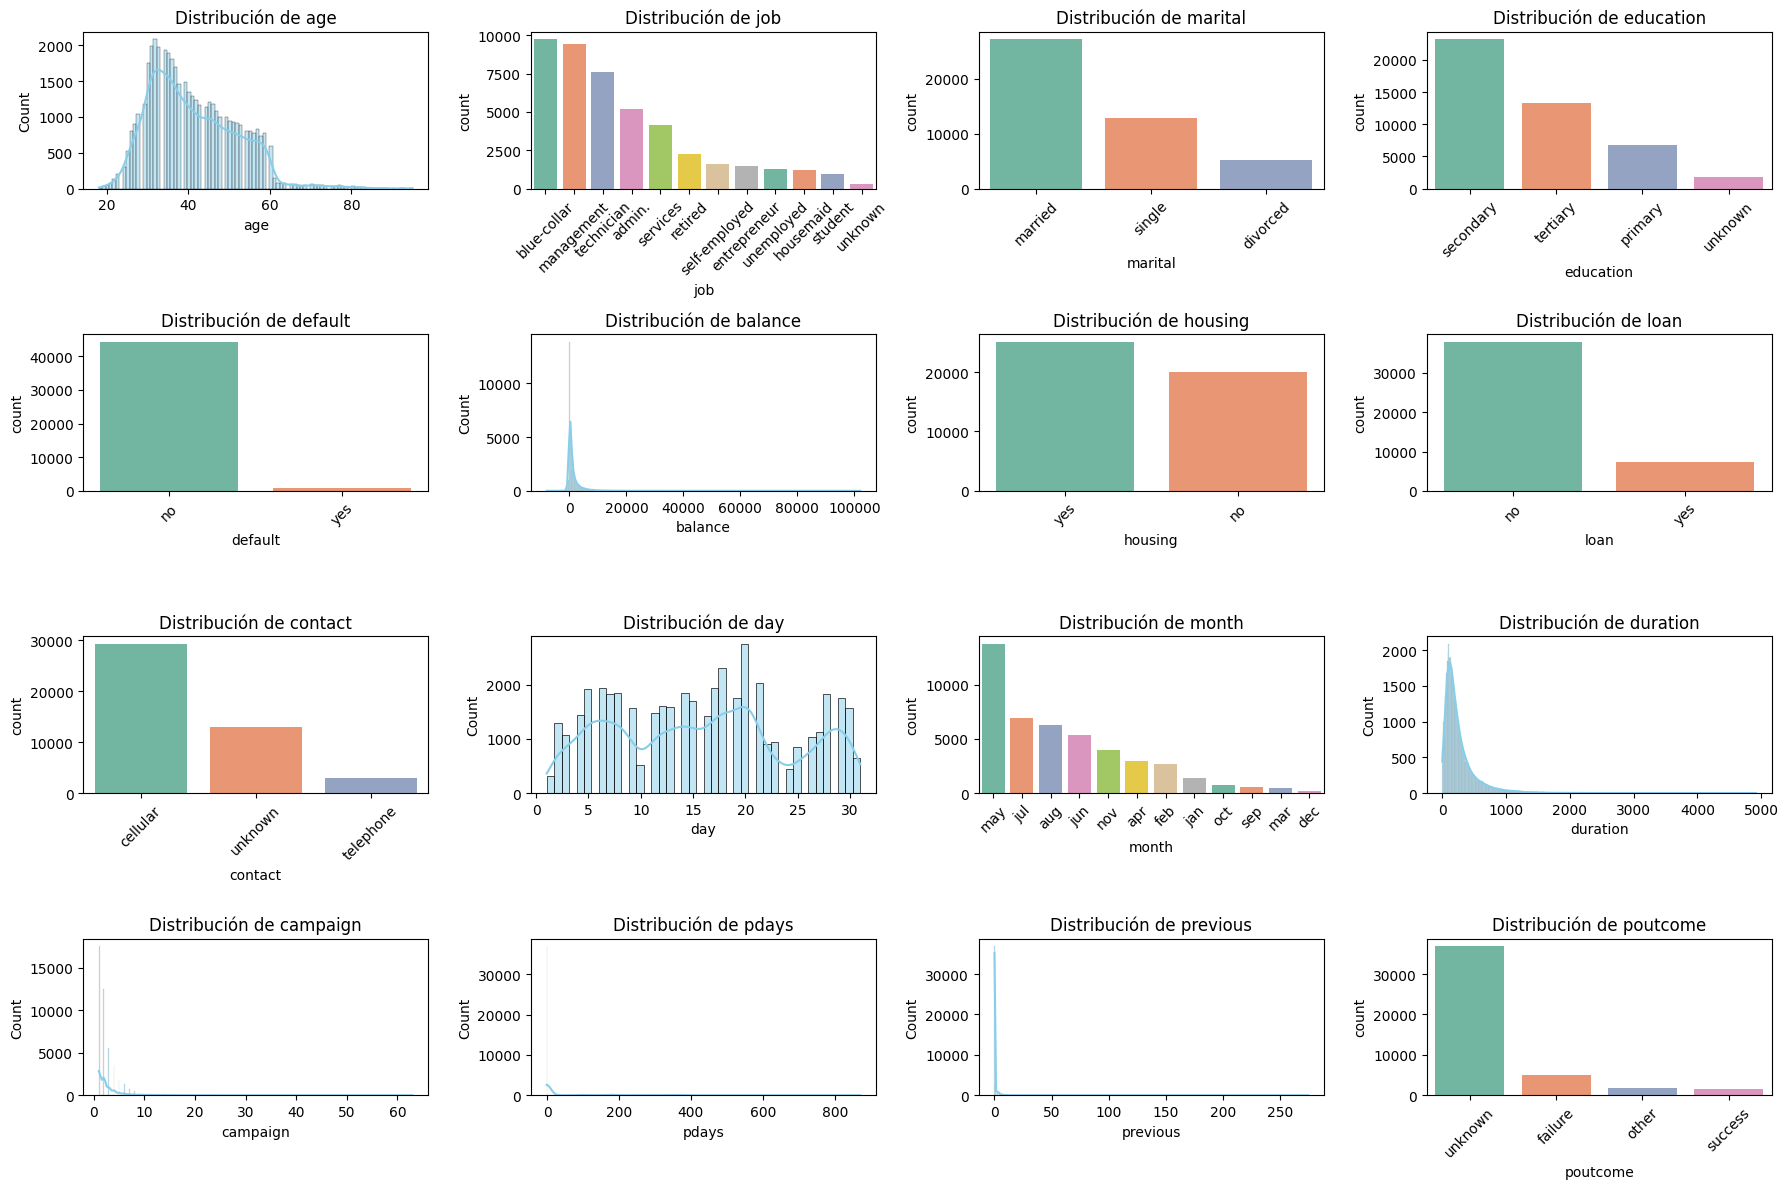

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

variables = ['age', 'job', 'marital', 'education', 'default', 'balance', 'housing',
       'loan', 'contact', 'day', 'month', 'duration', 'campaign', 'pdays',
       'previous', 'poutcome']
fig, axes = plt.subplots(nrows=4, ncols=4, figsize=(18, 12))
axes = axes.flatten()

for i, var in enumerate(variables):
    if df_bank[var].dtype == 'object':
        sns.countplot(data=df_bank, x=var, ax=axes[i], order=df_bank[var].value_counts().index, palette='Set2')
        axes[i].set_xticklabels(axes[i].get_xticklabels(), rotation=45)
    else:
        sns.histplot(data=df_bank, x=var, ax=axes[i], kde=True, color='skyblue')
    axes[i].set_title(f'Distribución de {var}')
    
plt.tight_layout()
plt.show()

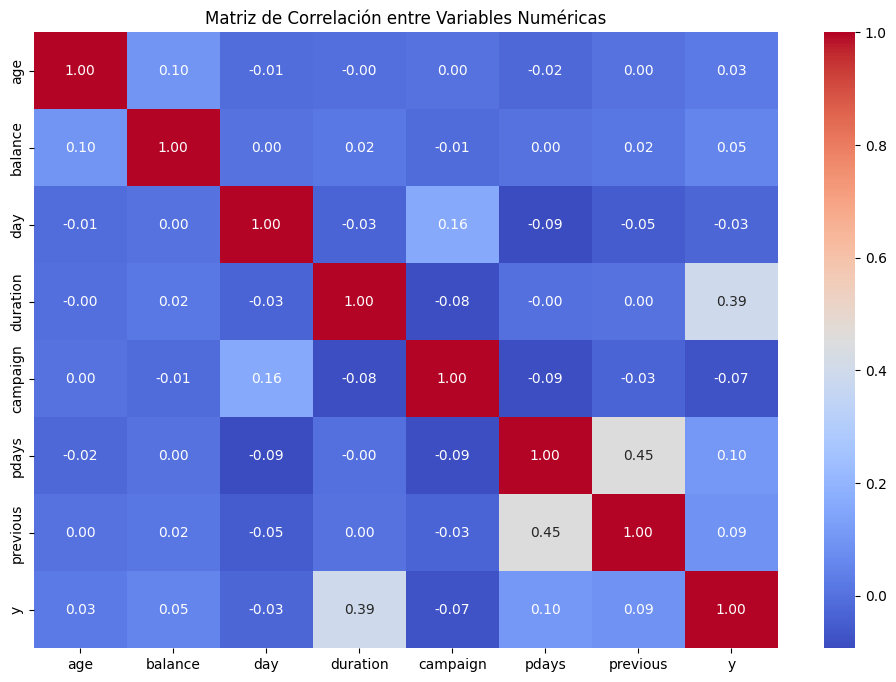

In [ ]:
df_bank_corr = df_bank.copy()
df_bank_corr['y'] = df_bank_corr['y'].map({'no': 0, 'yes': 1})

df_num = df_bank_corr.select_dtypes(include=['int64', 'float64'])

correlation_matrix = df_num.corr()

plt.figure(figsize=(12, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Matriz de Correlación entre Variables Numéricas")
plt.show()

Conversion de datos

In [8]:
cols_categoricas = ['job', 'marital', 'default', 'housing',
       'loan', 'contact', 'month', 'poutcome']

df_bank[cols_categoricas] = df_bank[cols_categoricas].astype('category')

df_bank['education'] = pd.Categorical(
    df_bank['education'], 
    categories=['primary', 'secondary', 'tertiary','unknown'], 
    ordered=True)

cols_categoricas_ordinales = ['education']

In [9]:
cols_numericas_decimales = ['balance']

df_bank[cols_numericas_decimales] = df_bank[cols_numericas_decimales].astype('float64')

In [10]:
cols_numericas_enteros = ['age', 'day', 'duration','campaign','pdays', 'previous']

df_bank[cols_numericas_enteros] = df_bank[cols_numericas_enteros].astype('int64')

In [11]:
df_bank.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45211 entries, 0 to 45210
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype   
---  ------     --------------  -----   
 0   age        45211 non-null  int64   
 1   job        45211 non-null  category
 2   marital    45211 non-null  category
 3   education  45211 non-null  category
 4   default    45211 non-null  category
 5   balance    45211 non-null  float64 
 6   housing    45211 non-null  category
 7   loan       45211 non-null  category
 8   contact    45211 non-null  category
 9   day        45211 non-null  int64   
 10  month      45211 non-null  category
 11  duration   45211 non-null  int64   
 12  campaign   45211 non-null  int64   
 13  pdays      45211 non-null  int64   
 14  previous   45211 non-null  int64   
 15  poutcome   45211 non-null  category
 16  y          45211 non-null  object  
dtypes: category(9), float64(1), int64(6), object(1)
memory usage: 3.1+ MB


In [12]:
df_bank.describe()

,age,balance,day,duration,campaign,pdays,previous
count,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000
mean,40.936210,1362.272058,15.806419,258.163080,2.763841,40.197828,0.580323
std,10.618762,3044.765829,8.322476,257.527812,3.098021,100.128746,2.303441
min,18.000000,-8019.000000,1.000000,0.000000,1.000000,-1.000000,0.000000
25%,33.000000,72.000000,8.000000,103.000000,1.000000,-1.000000,0.000000
50%,39.000000,448.000000,16.000000,180.000000,2.000000,-1.000000,0.000000
75%,48.000000,1428.000000,21.000000,319.000000,3.000000,-1.000000,0.000000
max,95.000000,102127.000000,31.000000,4918.000000,63.000000,871.000000,275.000000


In [13]:
df_bank.describe(include='category')

,job,marital,education,default,housing,loan,contact,month,poutcome
count,45211,45211,45211,45211,45211,45211,45211,45211,45211
unique,12,3,4,2,2,2,3,12,4
top,blue-collar,married,secondary,no,yes,no,cellular,may,unknown
freq,9732,27214,23202,44396,25130,37967,29285,13766,36959


Feature ingeniering

In [14]:
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, OrdinalEncoder
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

Creacion de pipelines

In [15]:
pipe_numerico = Pipeline(
    steps=[
        ('imputer', SimpleImputer(strategy='median'))
    ]
)

In [16]:
pipe_categorico = Pipeline(
    steps=[
        ('imputer', SimpleImputer(strategy='most_frequent')),
        ('encoder', OneHotEncoder(handle_unknown='ignore'))
    ]
)

In [17]:
pipe_categoric_ord = Pipeline(
    steps=[
        ('imputer', SimpleImputer(strategy='most_frequent')),
        ('encoder', OrdinalEncoder())
    ]
)

Creacion de column transformer

In [18]:
preprocessor = ColumnTransformer(
    transformers=[
        ('numericas', pipe_numerico, cols_numericas_decimales + cols_numericas_enteros),
        ('catergoricas_nominales', pipe_categorico, cols_categoricas),
        ('categoricas_ordinales', pipe_categoric_ord, cols_categoricas_ordinales)
    ]
)

preprocessor

,transformers,"[('numericas', ...), ('catergoricas_nominales', ...), ...]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True
,force_int_remainder_cols,'deprecated'
,missing_values,nan
,strategy,'median'
,fill_value,None


Dividir en train y test

In [19]:
X_features = df_bank.drop("y", axis="columns")
Y_target = df_bank['y']

Seleccionamos 80% entrenamiento y 20% para test

In [20]:
X_train, X_test, Y_train, Y_test = train_test_split(
    X_features, Y_target, test_size=0.2, random_state=100
)

In [21]:
X_train.shape, X_test.shape, Y_train.shape, Y_test.shape

((36168, 16), (9043, 16), (36168,), (9043,))

In [22]:
df_bank.head()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,58,management,married,tertiary,no,2143.0,yes,no,unknown,5,may,261,1,-1,0,unknown,no
1,44,technician,single,secondary,no,29.0,yes,no,unknown,5,may,151,1,-1,0,unknown,no
2,33,entrepreneur,married,secondary,no,2.0,yes,yes,unknown,5,may,76,1,-1,0,unknown,no
3,47,blue-collar,married,unknown,no,1506.0,yes,no,unknown,5,may,92,1,-1,0,unknown,no
4,33,unknown,single,unknown,no,1.0,no,no,unknown,5,may,198,1,-1,0,unknown,no


In [23]:
print(df_bank.columns.tolist())

['age', 'job', 'marital', 'education', 'default', 'balance', 'housing', 'loan', 'contact', 'day', 'month', 'duration', 'campaign', 'pdays', 'previous', 'poutcome', 'y']


Transformaciones 

In [24]:
datos_transformados = preprocessor.fit(X_train)

datos_transformados

,transformers,"[('numericas', ...), ('catergoricas_nominales', ...), ...]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True
,force_int_remainder_cols,'deprecated'
,missing_values,nan
,strategy,'median'
,fill_value,None


In [25]:
feature_names = preprocessor.get_feature_names_out()

feature_names

array(['numericas__balance', 'numericas__age', 'numericas__day',
       'numericas__duration', 'numericas__campaign', 'numericas__pdays',
       'numericas__previous', 'catergoricas_nominales__job_admin.',
       'catergoricas_nominales__job_blue-collar',
       'catergoricas_nominales__job_entrepreneur',
       'catergoricas_nominales__job_housemaid',
       'catergoricas_nominales__job_management',
       'catergoricas_nominales__job_retired',
       'catergoricas_nominales__job_self-employed',
       'catergoricas_nominales__job_services',
       'catergoricas_nominales__job_student',
       'catergoricas_nominales__job_technician',
       'catergoricas_nominales__job_unemployed',
       'catergoricas_nominales__job_unknown',
       'catergoricas_nominales__marital_divorced',
       'catergoricas_nominales__marital_married',
       'catergoricas_nominales__marital_single',
       'catergoricas_nominales__default_no',
       'catergoricas_nominales__default_yes',
       'catergoricas

In [26]:
X_train_transformed = preprocessor.transform(X_train)

X_train_transformed = pd.DataFrame(X_train_transformed, columns=feature_names)

X_train_transformed.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 36168 entries, 0 to 36167
Data columns (total 48 columns):
 #   Column                                     Non-Null Count  Dtype  
---  ------                                     --------------  -----  
 0   numericas__balance                         36168 non-null  float64
 1   numericas__age                             36168 non-null  float64
 2   numericas__day                             36168 non-null  float64
 3   numericas__duration                        36168 non-null  float64
 4   numericas__campaign                        36168 non-null  float64
 5   numericas__pdays                           36168 non-null  float64
 6   numericas__previous                        36168 non-null  float64
 7   catergoricas_nominales__job_admin.         36168 non-null  float64
 8   catergoricas_nominales__job_blue-collar    36168 non-null  float64
 9   catergoricas_nominales__job_entrepreneur   36168 non-null  float64
 10  catergoricas_nominales

In [27]:
X_train_transformed.head(5)

,numericas__balance,numericas__age,numericas__day,numericas__duration,numericas__campaign,numericas__pdays,numericas__previous,catergoricas_nominales__job_admin.,catergoricas_nominales__job_blue-collar,catergoricas_nominales__job_entrepreneur,...,catergoricas_nominales__month_mar,catergoricas_nominales__month_may,catergoricas_nominales__month_nov,catergoricas_nominales__month_oct,catergoricas_nominales__month_sep,catergoricas_nominales__poutcome_failure,catergoricas_nominales__poutcome_other,catergoricas_nominales__poutcome_success,catergoricas_nominales__poutcome_unknown,categoricas_ordinales__education
0,2.0,31.0,8.0,848.0,1.0,-1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,2.0
1,1521.0,41.0,8.0,46.0,4.0,-1.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0
2,474.0,59.0,21.0,252.0,1.0,-1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,2.0
3,1116.0,38.0,16.0,406.0,2.0,-1.0,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0
4,74.0,41.0,9.0,193.0,4.0,-1.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0


In [28]:
df_bank.to_parquet(DATA_DIR / "02_datos_con_tipo_de_dato_ajustado_banko.parquet")